# Challenge 01 - Valhalla
**Victor Misael Escalante Alvarado, A01741176**


El presente trabajo usa el conjunto de datos *valhalla.csv* para dar una conversion por medio de regresión lineal de *Valks* a **Celcius**. Este cuaderno hace uso de la libreria SciKitLearn.

In [32]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

### Lectura y carga del conjunto de datos


In [33]:
data_path = "data/Valhalla23.csv"
data = pd.read_csv(data_path)
data.head()

,Celsius,Valks
0,61.4720,-139.740
1,70.5790,-156.600
2,-7.3013,73.269
3,71.3380,-165.420
4,43.2360,-75.835


### Entrenamiento del modelo

In [34]:
X = data[["Valks"]]
y = data["Celsius"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Pendiente (m):    {model.coef_[0]:.6f}")
print(f"Intercepto (b):   {model.intercept_:.6f}")
print(f"\nEcuación: Celsius = {model.coef_[0]:.6f} * Valks + ({model.intercept_:.6f})")

Pendiente (m):    -0.333102
Intercepto (b):   16.748980

Ecuación: Celsius = -0.333102 * Valks + (16.748980)


### Evaluación del modelo

In [35]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")
print(f"R squared:   {r2:.6f}")

MSE:  2.3846
RMSE: 1.5442
R squared:   0.997559


### Visualización

/Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Desarrollo-de-Aplicaciones-Avanzadas/Desarrollo-Aplicaciones-Ciencias-Computacionales/regresion-lineal/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


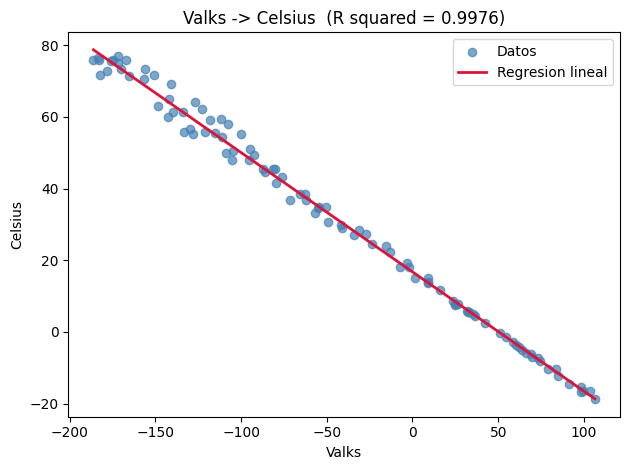

In [36]:
datos_puntos = np.linspace(data["Valks"].min(), data["Valks"].max(), 200).reshape(-1, 1)
lineamodel = model.predict(datos_puntos)

plt.scatter(data["Valks"], data["Celsius"], color="steelblue", alpha=0.7, label="Datos")
plt.plot(datos_puntos, lineamodel, color="crimson", linewidth=2, label="Regresion lineal")
plt.xlabel("Valks")
plt.ylabel("Celsius")
plt.title(f"Valks -> Celsius  (R squared = {r2:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

## Analysis de los resultados


Podemos ver como es que el modelo predice de manesa ratisfacotria las mediciones qeu tendran el celcis los disitntos valores de valks. La media de error es baja en incluso haciendo un analysis superficial de los datos completos (conjunto de todos los valores) podemos ver que , en efecto se sigue una tendencia